In [1]:
from langgraph.graph import StateGraph,START,END
from langchain_groq import ChatGroq
from typing import TypedDict,Literal,NotRequired
from dotenv import load_dotenv
load_dotenv()

c:\Users\ACER\OneDrive\Desktop\MACHINE LEARNING\Langraph\myvenv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


True

In [2]:
llm=ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0.8
)

In [3]:
class RevaluateState(TypedDict):
    question:str
    response:NotRequired[str]
    status:NotRequired[Literal["approved","retry"]]
    max_iteration:int 
    iteration:NotRequired[int]
    feedback:NotRequired[str]

In [4]:
def generate(state:RevaluateState):
    response=llm.invoke(f"Answer this question: {state['question']}")
    return {"response":response.content,"iteration":1}

In [5]:
def evaluate(state: RevaluateState):
    output = llm.invoke(f"""
You are an evaluation assistant responsible for reviewing an AI-generated response.

User Question:
{state["question"]}

Generated Answer:
{state["response"]}

Current Iteration:
{state["iteration"]}

Evaluation Criteria:
1. Accuracy
2. Completeness
3. Clarity
4. Relevance to the question

Instructions:
- If the answer is accurate, clear, and sufficiently complete, return status = \"approved\".
- If the answer has issues such as missing information, inaccuracies, or poor clarity, return status = \"retry\".
- Provide short feedback explaining what needs improvement.

Output format:

status: \"approved\" or \"retry\"
feedback: brief explanation of what needs improvement
""")

    response_text = output.content.lower()
    status = "approved" if "approved" in response_text else "retry"
    feedback = output.content.split("feedback:")[-1].strip() if "feedback:" in output.content else output.content
    
    return {
        "status": status,
        "feedback": feedback,
        "iteration": state["iteration"]
    }

In [6]:
def check_status(state:RevaluateState):
    if state["status"]=="approved":
        return "approved"
    elif state["status"]=="retry" and state["iteration"]<state["max_iteration"]:
        return "optimize"

In [7]:
def optimize(state:RevaluateState):
    response2=llm.invoke(f"""You are an AI assistant responsible for improving a previously generated answer.

User Question:
{state["question"]}

Previous Answer:
{state["response"]}

Feedback from Evaluation:
{state["feedback"]}

Task:
Improve the previous answer using the evaluator's feedback.

Instructions:
- Carefully analyze the feedback and correct the issues mentioned.
- Improve accuracy, completeness, clarity, and relevance.
- Ensure the improved answer directly addresses the user's question.

Provide only the improved answer.""")
    
    return {"response":response2.content,"iteration":state["iteration"]+1}

In [8]:
def approved(state:RevaluateState):
    return {
        "question": state["question"],
        "response": state["response"],
        "status": state["status"],
        "total_iteration": state["iteration"],
        "max_iteration": state["max_iteration"]
    }

In [9]:
graph=StateGraph(RevaluateState)

graph.add_node("generate",generate)
graph.add_node("evaluate",evaluate)
graph.add_node("approved",approved)
graph.add_node("optimize",optimize)

graph.add_edge(START,"generate")
graph.add_edge("generate","evaluate")
graph.add_conditional_edges("evaluate",check_status,["approved","optimize"])
graph.add_edge("optimize","evaluate")
graph.add_edge("approved",END)

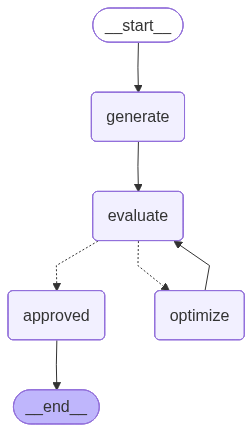

In [10]:
workflow=graph.compile()
workflow

In [11]:
initial_state={"question":"Explain Retrieval-Augmented Generation (RAG) to a beginner.",
               "max_iteration":5}

In [18]:
output_state=workflow.invoke(initial_state)
print(output_state["iteration"])

1


In [19]:
print(output_state["response"])

Retrieval-Augmented Generation (RAG) is a technique used in natural language processing (NLP) and artificial intelligence (AI) to improve the generation of text. I'll break it down in simple terms.

**What is text generation?**
Text generation is the process of creating text automatically using a computer program. This can include tasks like writing articles, generating chatbot responses, or even creating entire books. The goal is to produce coherent and meaningful text that sounds like it was written by a human.

**What's the problem with traditional text generation?**
Traditional text generation methods often rely on large language models that are trained on vast amounts of text data. These models learn patterns and relationships in language, but they can struggle with certain aspects, such as:

1. **Lack of context**: Generated text might not be relevant to the specific topic or conversation.
2. **Limited knowledge**: The model might not have access to the latest information or doma